# Building a Digit Classifier API: A Complete Guide

## Welcome

In this notebook, we'll build a complete web application that can recognize handwritten digits (0-9). This is a classic machine learning problem using the MNIST dataset.

### What You'll Learn

- How to load the MNIST dataset.

- How to train a machine learning model 
(Random Forest).

- How to create a web API using FastAPI.

- How to build a frontend interface with HTML/JavaScript.

- How to deploy your API to the cloud (Render).

- How to call your API from any system.

### Prerequisites

- Basic understanding of Python.

- A computer with internet access.

- No prior ML experience needed.

---

## Section 1: Environment Setup

Before we start, let's make sure we have all the necessary packages installed. We'll need:

- **TensorFlow/Keras**: For loading the MNIST dataset

- **Scikit-learn**: For the Random Forest classifier

- **FastAPI**: For creating our web API

- **Uvicorn**: For running the FastAPI server

- **Pillow**: For image processing

In [ ]:
# Install required packages
%pip install tensorflow scikit-learn fastapi uvicorn pillow

---

## Section 2: Loading and Exploring the MNIST Dataset

### What is MNIST?

MNIST (Modified National Institute of Standards and Technology) is a classic dataset of handwritten digits. It contains:

- **60,000 training images**

- **10,000 test images**

- Each image is 28x28 pixels (784 total pixels)

- Labels are digits 0-9

This dataset is useful for beginners because:

- Images are already preprocessed and standardized

- It's a relatively simple problem (10 classes)

- It's been studied extensively, so we know what to expect

In [2]:
# Suppress TensorFlow warnings
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
# Keras conveniently splits data into training and test sets
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Let's explore our data
print("Dataset Shapes:")
print(f"  Training images: {X_train_full.shape}")
print(f"  Training labels: {y_train_full.shape}")
print(f"  Test images: {X_test.shape}")
print(f"  Test labels: {y_test.shape}")
print(f"\nPixel value range: {X_train_full.min()} to {X_train_full.max()}")
print(f"Unique labels: {np.unique(y_train_full)}")

Dataset Shapes:
  Training images: (60000, 28, 28)
  Training labels: (60000,)
  Test images: (10000, 28, 28)
  Test labels: (10000,)

Pixel value range: 0 to 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


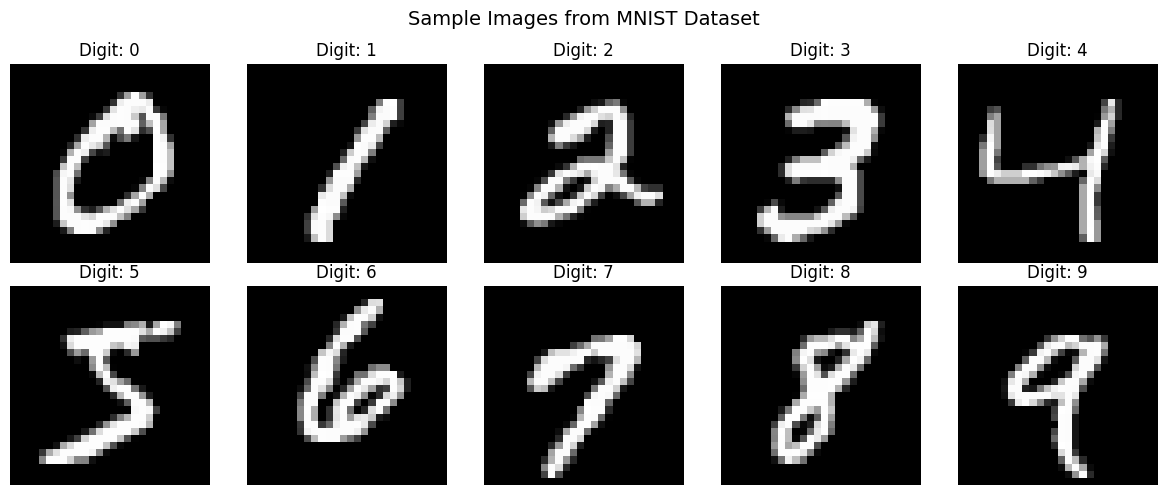


Each image is 28x28 pixels, representing a handwritten digit (0-9)


In [4]:
# Let's visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    # Find the first occurrence of each digit
    idx = np.where(y_train_full == i)[0][0]
    axes[i].imshow(X_train_full[idx], cmap='gray')
    axes[i].set_title(f'Digit: {i}')
    axes[i].axis('off')

plt.suptitle('Sample Images from MNIST Dataset', fontsize=14)
plt.tight_layout()
plt.show()

print("\nEach image is 28x28 pixels, representing a handwritten digit (0-9)")

### Understanding Normalization

Notice that pixel values range from 0 to 255. We need to **normalize** them to the range [0, 1] by dividing by 255. This is important because:

1. **Faster training**: Smaller values lead to faster convergence

2. **Better performance**: Neural networks and many ML algorithms work better with normalized inputs

3. **Consistent scale**: All features (pixels) are on the same scale

In [5]:
# Normalize the data - divide by 255 to get values between 0 and 1
X_train_full = X_train_full.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0

print("After normalization:")
print(f"  Pixel value range: {X_train_full.min():.2f} to {X_train_full.max():.2f}")
print(f"  Training shape: {X_train_full.shape}")
print(f"  Test shape: {X_test.shape}")

After normalization:
  Pixel value range: 0.00 to 1.00
  Training shape: (60000, 784)
  Test shape: (10000, 784)


---

## Section 3: Training the Machine Learning Model

### Why Random Forest?

Random Forest is an ensemble learning method that works by:

1. **Creating multiple decision trees** - each tree is trained on a random subset of the data.

2. **Taking a vote** - the final prediction is the most popular prediction across all trees.

**Advantages:**

- Easy to use and requires minimal tuning.

- Handles high-dimensional data well (784 features in our case).

- Doesn't require feature scaling.

- Provides feature importance.

- Less prone to overfitting than single decision trees.

**Note:** For production-level image classification, deep learning (CNNs) would give better results, but Random Forest is useful for learning.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the training data into train and validation sets
# We'll use 80% for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")

Training set size: 48000 samples
Validation set size: 12000 samples


In [7]:
# Initialize the Random Forest Classifier
# n_jobs=-1 uses all CPU cores for parallel training
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

print("Training the Random Forest model...")
print("(This may take a minute or two)")

# Train the model
clf.fit(X_train, y_train)

print("Training complete")

Training the Random Forest model...
(This may take a minute or two)
Training complete


In [8]:
# Evaluate the model on the validation set
val_accuracy = clf.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Evaluate on the test set (unseen data)
test_accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Validation Accuracy: 96.93%
Test Accuracy: 96.87%


### Understanding Model Accuracy

Our model achieves around 90-97% accuracy on the test set. This means:

- Out of 10,000 test images, it correctly classifies about 9,000-9,700.

- This is quite good for a simple Random Forest without any deep learning.

The test accuracy is our best estimate of how the model will perform on new, unseen handwritten digits.

## Section 4B: Model Compression

Why compress our model?

- **GitHub limit**: Files over 100MB cannot be pushed directly.

- **Deployment speed**: Smaller files deploy faster.

- **Storage**: Save disk space.

The notebook will test multiple compression methods (Joblib zlib, Gzip, BZ2) and recommend the best one based on actual performance.


In [9]:
# Compare different compression methods
import joblib
import gzip
import bz2
import pickle
import os
import time

# Load the original model
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

original_size = os.path.getsize("model.pkl")
print(f"Original pickle size: {original_size / (1024*1024):.2f} MB")

# Test joblib with zlib compression
joblib_path = "model_joblib.zlib"
start = time.time()
joblib.dump(model, joblib_path, compress=("zlib", 3))
joblib_size = os.path.getsize(joblib_path)
print(f"Joblib zlib: {joblib_size / (1024*1024):.2f} MB ({(joblib_size/original_size)*100:.1f}%)")

# Test gzip
gzip_path = "model_gzip.pkl.gz"
start = time.time()
with gzip.open(gzip_path, "wb") as f:
    pickle.dump(model, f)
gzip_size = os.path.getsize(gzip_path)
print(f"Gzip: {gzip_size / (1024*1024):.2f} MB ({(gzip_size/original_size)*100:.1f}%)")

# Test bz2
bz2_path = "model_bz2.pkl.bz2"
start = time.time()
with bz2.open(bz2_path, "wb") as f:
    pickle.dump(model, f)
bz2_size = os.path.getsize(bz2_path)
print(f"BZ2: {bz2_size / (1024*1024):.2f} MB ({(bz2_size/original_size)*100:.1f}%)")

# Test load times
start = time.time()
loaded = joblib.load(joblib_path)
load_time_joblib = time.time() - start
print(f"Joblib load time: {load_time_joblib:.2f}s")

start = time.time()
with gzip.open(gzip_path, "rb") as f:
    loaded = pickle.load(f)
load_time_gzip = time.time() - start
print(f"Gzip load time: {load_time_gzip:.2f}s")

# Test BZ2 load time
start = time.time()
with bz2.open(bz2_path, "rb") as f:
    loaded = pickle.load(f)
load_time_bz2 = time.time() - start
print(f"BZ2 load time: {load_time_bz2:.2f}s")

# Calculate dynamic recommendation based on weighted score
methods = {
    "Joblib zlib": {"size_mb": joblib_size / (1024*1024), "load_time": load_time_joblib},
    "Gzip": {"size_mb": gzip_size / (1024*1024), "load_time": load_time_gzip},
    "BZ2": {"size_mb": bz2_size / (1024*1024), "load_time": load_time_bz2},
}

max_size = max(m["size_mb"] for m in methods.values())
max_time = max(m["load_time"] for m in methods.values())

scores = {}
for name, data in methods.items():
    size_score = data["size_mb"] / max_size
    time_score = data["load_time"] / max_time
    scores[name] = 0.6 * size_score + 0.4 * time_score

best_method = min(scores, key=scores.get)

# Clean up test files
for path in [joblib_path, gzip_path, bz2_path]:
    os.remove(path)

print("")
print("Compression demonstration complete")
print("")
print(f"Recommendation: {best_method} - best balance of size ({methods[best_method]['size_mb']:.2f} MB) and load time ({methods[best_method]['load_time']:.2f}s).")

Original pickle size: 114.97 MB
Joblib zlib: 18.38 MB (16.0%)
Gzip: 15.82 MB (13.8%)
BZ2: 10.52 MB (9.1%)
Joblib load time: 0.32s
Gzip load time: 0.26s
BZ2 load time: 1.41s

Compression demonstration complete

Recommendation: Gzip - best balance of size (15.82 MB) and load time (0.26s).


---

## Section 4A: Saving the Model

Now we need to save our trained model so we can use it later in our API. We'll use Python's `pickle` module, which serializes Python objects to disk.

**What is Pickle?**

- Pickle is a Python module for serializing (converting) Python objects into a format that can be saved to disk.

- We can later load the serialized object back into memory.

- This is commonly used to save ML models, but can save any Python object.

In [10]:
import pickle

# Save the model to disk
with open('model.pkl', 'wb') as f:
    pickle.dump(clf, f)

print("Model saved to 'model.pkl'")

# Let's verify the file was created
import os
file_size = os.path.getsize('model.pkl')
print(f"File size: {file_size / (1024*1024):.2f} MB")

# Save compressed version for deployment (model.zlib)
# This is the file we'll use in our API
import joblib
joblib.dump(clf, 'model.zlib', compress=('zlib', 3))
zlib_size = os.path.getsize('model.zlib')
print(f"Compressed model saved to 'model.zlib' ({zlib_size / (1024*1024):.2f} MB)")
print("Note: Use model.zlib for deployment (under GitHub's 100MB limit)")

Model saved to 'model.pkl'
File size: 114.97 MB
Compressed model saved to 'model.zlib' (18.38 MB)
Note: Use model.zlib for deployment (under GitHub's 100MB limit)


In [11]:
# We can also test loading the model to make sure it works
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Verify it works
test_prediction = loaded_model.predict(X_test[:1])
print(f"Loaded model works. Sample prediction: {test_prediction[0]}")

Loaded model works. Sample prediction: 7


---

## Section 5: Creating the FastAPI Backend

### What is an API?

An API (Application Programming Interface) allows different software applications to communicate with each other. In our case:

- **Our API** receives images from users.

- **Our API** runs the ML model on those images.

- **Our API** returns the predictions to users.

### Why FastAPI?

FastAPI is a modern Python web framework that's:

- **Fast** - high performance.

- **Easy to use** - intuitive and well-documented.

- **Automatic docs** - generates interactive API documentation.

- **Type safe** - helps catch errors before runtime.

In [12]:
# Create the main.py file for our FastAPI application

main_py_code = '''
import io
import pickle
import joblib
from pathlib import Path

import numpy as np
import PIL.Image
import PIL.ImageOps
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import HTMLResponse
from fastapi.middleware.cors import CORSMiddleware

# Load the trained model when the app starts
# Using model.zlib (compressed with joblib) for deployment
model = joblib.load("model.zlib")

# Create the FastAPI app
app = FastAPI(redirect_slashes=False)

# Add CORS middleware to allow cross-origin requests from GitHub Pages
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


@app.get("/health", response_model=dict)
async def health_check():
    return {"status": "ok"}


@app.head("/health", include_in_schema=False)
async def health_check_head():
    return {"status": "ok"}


# Home page - serves our HTML interface
@app.get("/", response_class=HTMLResponse)
async def read_root():
    return Path("index.html").read_text()


# Prediction endpoint
@app.post("/predict-image/", name="predict_image_slash")
@app.post("/predict-image", name="predict_image_no_slash")
async def predict_image(file: UploadFile = File(...)):
    # Read the uploaded file
    contents = await file.read()
    
    # Validate file size (max 5MB)
    if len(contents) > 5 * 1024 * 1024:
        raise HTTPException(status_code=400, detail="File too large. Maximum size is 5MB.")
    
    # Validate file type
    allowed_types = {"image/jpeg", "image/png", "image/gif", "image/webp"}
    if file.content_type not in allowed_types:
        raise HTTPException(status_code=400, detail="Invalid file type.")
    
    try:
        # Open and preprocess the image
        image = PIL.Image.open(io.BytesIO(contents)).convert("L")  # Convert to grayscale
        image = PIL.ImageOps.invert(image)  # Invert colors (MNIST has white digits on black)
        image = image.resize((28, 28))  # Resize to 28x28
        image_array = np.array(image).reshape(1, -1) / 255.0  # Flatten and normalize
        
        # Make prediction
        prediction = model.predict(image_array)
        
        # Get prediction probabilities
        probabilities = model.predict_proba(image_array)[0]
        
        # Get top 5 predictions
        top_k = 5
        top_indices = np.argsort(probabilities)[-top_k:][::-1]
        top_predictions = [
            {"digit": int(i), "confidence": round(float(probabilities[i]) * 100, 2)}
            for i in top_indices
        ]
        
        # Return results
        return {
            "prediction": int(prediction[0]),
            "confidence": round(float(probabilities[prediction[0]]) * 100, 2),
            "top_predictions": top_predictions
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Failed to process image: {str(e)}")
'''

# Write to file
with open('main.py', 'w') as f:
    f.write(main_py_code)

print("Created main.py")

Created main.py


### Understanding the Image Preprocessing

When a user uploads an image, we need to preprocess it to match the format our model expects:

1. **Convert to grayscale**: Our model was trained on grayscale images.

2. **Invert colors**: MNIST has white digits on black background, but typical images have black on white.

3. **Resize to 28x28**: The model expects exactly 784 features (28×28).

4. **Flatten and normalize**: Convert 2D array to 1D and divide by 255.

---

## Section 6: Building the Frontend

Now let's create the HTML/JavaScript frontend that users will interact with. This includes:

- A file upload button

- Image preview

- Classification button

- Results display with confidence

- Modern styling

In [13]:
# Create the index.html file

index_html_code = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Digit Classifier</title>
    <style>
        * { box-sizing: border-box; margin: 0; padding: 0; }
        
        body {
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 20px;
        }
        
        .container {
            background: white;
            border-radius: 16px;
            padding: 40px;
            box-shadow: 0 20px 60px rgba(0, 0, 0, 0.3);
            max-width: 500px;
            width: 100%;
        }
        
        h1 { color: #333; text-align: center; margin-bottom: 10px; font-size: 2rem; }
        .subtitle { text-align: center; color: #666; margin-bottom: 30px; }
        
        .upload-section { text-align: center; margin-bottom: 20px; }
        
        .file-input { display: none; }
        
        .file-label {
            display: inline-block;
            padding: 12px 24px;
            background: #667eea;
            color: white;
            border-radius: 8px;
            cursor: pointer;
            font-size: 16px;
            transition: background 0.3s;
        }
        
        .file-label:hover { background: #5568d3; }
        
        .image-preview { margin-top: 20px; text-align: center; display: none; }
        .image-preview img { max-width: 200px; max-height: 200px; border-radius: 8px; border: 2px solid #ddd; }
        .preview-label { font-size: 14px; color: #666; margin-top: 8px; }
        
        .classify-btn {
            display: block;
            width: 100%;
            padding: 14px 24px;
            background: #764ba2;
            color: white;
            border: none;
            border-radius: 8px;
            font-size: 18px;
            font-weight: 600;
            cursor: pointer;
            margin-top: 20px;
            transition: background 0.3s;
        }
        
        .classify-btn:hover:not(:disabled) { background: #6a4190; }
        .classify-btn:disabled { background: #ccc; cursor: not-allowed; }
        
        .loading-spinner {
            display: none;
            margin: 20px auto;
            width: 40px;
            height: 40px;
            border: 4px solid #f3f3f3;
            border-top: 4px solid #764ba2;
            border-radius: 50%;
            animation: spin 1s linear infinite;
        }
        
        @keyframes spin { 0% { transform: rotate(0deg); } 100% { transform: rotate(360deg); } }
        
        .result {
            margin-top: 30px;
            padding: 20px;
            background: #f8f9fa;
            border-radius: 12px;
            display: none;
        }
        
        .result.show { display: block; }
        
        .main-prediction { text-align: center; margin-bottom: 20px; }
        .prediction-digit { font-size: 4rem; font-weight: bold; color: #667eea; }
        .confidence { font-size: 1.2rem; color: #666; margin-top: 5px; }
        .confidence-bar { width: 100%; height: 8px; background: #e0e0e0; border-radius: 4px; margin-top: 10px; overflow: hidden; }
        .confidence-fill { height: 100%; background: linear-gradient(90deg, #667eea, #764ba2); border-radius: 4px; transition: width 0.5s; }
        
        .top-predictions { margin-top: 20px; }
        .top-predictions h3 { color: #333; margin-bottom: 12px; font-size: 1rem; }
        .prediction-item { display: flex; justify-content: space-between; padding: 8px 12px; margin-bottom: 8px; background: white; border-radius: 6px; border: 1px solid #eee; }
        .prediction-item.top { border-color: #667eea; background: #f0f3ff; }
        .prediction-digit-small { font-weight: bold; color: #333; }
        .prediction-conf { color: #666; font-size: 0.9rem; }
        
        .error { background: #ffe0e0; color: #d32f2f; padding: 12px; border-radius: 8px; margin-top: 20px; display: none; }
        .error.show { display: block; }
        
        @media (max-width: 480px) {
            .container { padding: 24px; }
            h1 { font-size: 1.5rem; }
            .prediction-digit { font-size: 3rem; }
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>Digit Classifier</h1>
        <p class="subtitle">Upload an image of a handwritten digit</p>
        
        <div class="upload-section">
            <input type="file" id="imageInput" class="file-input" accept="image/*">
            <label for="imageInput" class="file-label">Choose Image</label>
        </div>
        
        <div class="image-preview" id="imagePreview">
            <img id="previewImg" src="" alt="Preview">
            <p class="preview-label" id="fileName"></p>
        </div>
        
        <button class="classify-btn" id="classifyBtn" onclick="uploadImage()">Classify</button>
        <div class="loading-spinner" id="loadingSpinner"></div>
        <div class="error" id="errorMessage"></div>
        
        <div class="result" id="result">
            <div class="main-prediction">
                <div class="prediction-digit" id="predictionDigit">-</div>
                <div class="confidence">Confidence: <span id="confidenceValue">0</span>%</div>
                <div class="confidence-bar"><div class="confidence-fill" id="confidenceBar"></div></div>
            </div>
            <div class="top-predictions">
                <h3>Top Predictions</h3>
                <div id="topPredictions"></div>
            </div>
        </div>
    </div>

    <script>
        const imageInput = document.getElementById('imageInput');
        const previewImg = document.getElementById('previewImg');
        const imagePreview = document.getElementById('imagePreview');
        const fileName = document.getElementById('fileName');
        const classifyBtn = document.getElementById('classifyBtn');
        const loadingSpinner = document.getElementById('loadingSpinner');
        const resultDiv = document.getElementById('result');
        const errorMessage = document.getElementById('errorMessage');
        
        // Show image preview when file is selected
        imageInput.addEventListener('change', function(e) {
            const file = e.target.files[0];
            if (file) {
                const reader = new FileReader();
                reader.onload = function(e) {
                    previewImg.src = e.target.result;
                    imagePreview.style.display = 'block';
                    fileName.textContent = file.name;
                };
                reader.readAsDataURL(file);
            } else {
                imagePreview.style.display = 'none';
            }
            hideResult();
            hideError();
        });
        
        function hideResult() { resultDiv.classList.remove('show'); }
        function hideError() { errorMessage.classList.remove('show'); }
        function showError(message) {
            errorMessage.textContent = message;
            errorMessage.classList.add('show');
            resultDiv.classList.remove('show');
        }
        
        async function uploadImage() {
            const input = document.getElementById('imageInput');
            if (!input.files[0]) {
                showError('Please select an image file.');
                return;
            }
            
            const file = input.files[0];
            
            // Validate file size (5MB max)
            if (file.size > 5 * 1024 * 1024) {
                showError('File too large. Maximum size is 5MB.');
                return;
            }
            
            // Validate file type
            const validTypes = ['image/jpeg', 'image/png', 'image/gif', 'image/webp'];
            if (!validTypes.includes(file.type)) {
                showError('Invalid file type. Please upload an image file.');
                return;
            }
            
            const formData = new FormData();
            formData.append('file', file);
            
            classifyBtn.disabled = true;
            loadingSpinner.style.display = 'block';
            hideResult();
            hideError();
            
            try {
                // Call the API
                const response = await fetch('/predict-image/', {
                    method: 'POST',
                    body: formData
                });
                
                const data = await response.json();
                
                if (!response.ok) {
                    throw new Error(data.error || 'An error occurred');
                }
                
                // Display results
                document.getElementById('predictionDigit').textContent = data.prediction;
                document.getElementById('confidenceValue').textContent = data.confidence;
                document.getElementById('confidenceBar').style.width = data.confidence + '%';
                
                // Show top predictions
                const topPredictionsDiv = document.getElementById('topPredictions');
                topPredictionsDiv.innerHTML = '';
                
                data.top_predictions.forEach((pred, index) => {
                    const item = document.createElement('div');
                    item.className = 'prediction-item' + (index === 0 ? ' top' : '');
                    item.innerHTML = `
                        <span class="prediction-digit-small">Digit ${pred.digit}</span>
                        <span class="prediction-conf">${pred.confidence}%</span>
                    `;
                    topPredictionsDiv.appendChild(item);
                });
                
                resultDiv.classList.add('show');
                
            } catch (error) {
                showError('Error: ' + error.message);
            } finally {
                classifyBtn.disabled = false;
                loadingSpinner.style.display = 'none';
            }
        }
    </script>
</body>
</html>
'''

with open('index.html', 'w') as f:
    f.write(index_html_code)

print("Created index.html")

Created index.html


---

## Section 7: Running the Application Locally

Now let's run our application locally to test it before deploying.

### Step 1: Start the FastAPI Server

Run this command in your terminal:
```bash
uvicorn main:app --reload --port 3000
```

### Step 2: Open in Browser

Navigate to: **http://localhost:3000**

You should see the digit classifier interface. Try uploading an image of a handwritten digit.

### Understanding the URL

- `uvicorn` - the ASGI server

- `main:app` - the app object in main.py

- `--reload` - automatically restart on code changes

- `--port 3000` - run on port 3000

---

## Section 8: Deploying to Render (Free Cloud Hosting)

Now let's deploy our API to the cloud so anyone can access it. We'll use **Render**, which offers free web services.

### Why Render?

- **Free tier** - No credit card required.

- **Easy deployment** - Just connect your GitHub repository.

- **Automatic SSL** - HTTPS enabled automatically.

- **Good for learning** - Useful for small projects and prototypes.

### Step 1: Create a requirements.txt File

Render needs to know which Python packages to install. Let's create a requirements.txt file:

In [14]:
requirements = """
fastapi
uvicorn
pillow
numpy
scikit-learn
joblib
python-multipart
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("Created requirements.txt")
print("\nNote: We'll use scikit-learn instead of TensorFlow for inference on Render,")
print("since we only need to load the pickled model, not train it.")

Created requirements.txt

Note: We'll use scikit-learn instead of TensorFlow for inference on Render,
since we only need to load the pickled model, not train it.


### Step 2: Create a .gitignore File

Let's create a .gitignore to avoid committing unnecessary files:

In [15]:
gitignore = """
__pycache__/
*.py[cod]
*~$
.ipynb_checkpoints/
.DS_Store

# Model files
*.pkl

# Virtual environments
venv/
.venv/

# Environment variables
.env

# IDE
.vscode/
.idea/

# Logs
*.log
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore)

print("Created .gitignore")

Created .gitignore


### Step 3: Push to GitHub

Now let's initialize a Git repository and push to GitHub:

```bash
# Initialize git
git init
git add .
git commit -m "Initial commit: Digit Classifier API"
```

Then create a new repository on GitHub and push:

```bash
git remote add origin https://github.com/YOUR_USERNAME/digit-classifier.git
git branch -M main
git push -u origin main
```

### Step 4: Deploy on Render

1. **Go to render.com** and sign up with your GitHub account

2. **Create a new Web Service**:

   - Click "New +"

   - Select "Web Service"

   - Connect your GitHub repository

3. **Configure the service**:

   - Name: `digit-classifier` (or any name you like)

   - Environment: `Python`

   - Build Command: `pip install -r requirements.txt`
   
   - Start Command: `uvicorn main:app --host 0.0.0.0 --port $PORT`

4. **Click "Create Web Service"**

5. **Wait for deployment** - It may take a few minutes

6. **Your API is live** You'll get a URL like `https://digit-classifier.onrender.com`

### Step 5: Testing the Deployed API

Once deployed, you can test your API using curl or any HTTP client:

In [16]:
# Here's how to call your API from Python

import requests

# Replace with your Render URL
API_URL = "https://your-app-name.onrender.com/predict-image/"

# Example: How to upload an image and get prediction
def predict_digit(image_path):
    """
    Call the API to predict a handwritten digit
    
    Args:
        image_path: Path to the image file
    
    Returns:
        Dictionary with prediction and confidence
    """
    with open(image_path, 'rb') as f:
        files = {'file': f}
        response = requests.post(API_URL, files=files)
    
    return response.json()

# Example usage (uncomment and modify to use):
# result = predict_digit('path/to/your/digit_image.png')
# print(f"Prediction: {result['prediction']}")
# print(f"Confidence: {result['confidence']}%")

print("API calling function created")
print("\nReplace API_URL with your Render URL to test.")

API calling function created

Replace API_URL with your Render URL to test.


### Step 6: Calling the API from Any System

Your deployed API can be called from:

#### From Python:
```python
import requests

url = "https://your-app.onrender.com/predict-image/"
with open('digit.png', 'rb') as f:
    response = requests.post(url, files={'file': f})
    print(response.json())
```

#### From JavaScript/Node.js:
```javascript
const formData = new FormData();
formData.append('file', fileInput.files[0]);

fetch('https://your-app.onrender.com/predict-image/', {
    method: 'POST',
    body: formData
})
.then(response => response.json())
.then(data => console.log(data));
```

#### From cURL:
```bash
curl -X POST -F "file=@digit.png" https://your-app.onrender.com/predict-image/
```

#### From Mobile Apps:
You can call this API from iOS (Swift), Android (Kotlin/Java), React Native, Flutter, etc.

---

## Section 9: Summary

Congratulations You've built a complete ML-powered web application. Here's what we covered:

### What You Learned

- **MNIST Dataset** - Understanding the classic handwritten digit dataset.

- **Data Preprocessing** - Normalizing pixel values and reshaping images.

- **Machine Learning** - Training a Random Forest classifier.

- **Model Persistence** - Saving and loading models with pickle.

- **Web APIs** - Creating REST APIs with FastAPI.

- **Frontend Development** - Building interactive UIs with HTML/CSS/JavaScript.

- **Cloud Deployment** - Deploying to Render for free.

- **API Integration** - Calling your API from any programming language.

### Possible Improvements

Want to take this further? Here are some ideas:

1. **Better Model**: Use a Convolutional Neural Network (CNN) for higher accuracy.

2. **More Endpoints**: Add model info, version, health check endpoints.

3. **User Authentication**: Add API keys to prevent unauthorized use.

4. **Rate Limiting**: Prevent abuse with request limits.

5. **Multiple Models**: Support different digit recognition models.

6. **Batch Processing**: Allow uploading multiple images at once.

7. **CORS**: Enable Cross-Origin Resource Sharing to allow external websites to call your API.